# Tratamento dos dados


In [36]:
%%html
<link rel="stylesheet" href="./style.css">

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

from columns import numeric_columns
from data import scaled_df


In [38]:
def generate_correlation_matrix(matrix: pd.DataFrame, title: str):
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        matrix,
        # annot=True,  # mostra os valores
        # fmt=".2f",  # duas casas decimais
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [39]:
def analyse_correlation(numeric_columns: pd.Series):

    spearman_correlation = numeric_columns.corr(method="spearman")
    generate_correlation_matrix(
        spearman_correlation, "Matriz de correlação de Spearman"
    )

    pearson_correlation = numeric_columns.corr(method="pearson")
    generate_correlation_matrix(pearson_correlation, "Matriz de correlação de Pearson")

    pearson_correlation_abs = pearson_correlation.abs()
    pairs = (
        pearson_correlation_abs.where(
            np.triu(np.ones(pearson_correlation_abs.shape), k=1).astype(bool)
        )
        .stack()
        .sort_values(ascending=False)
    )
    strong_pairs = pairs[pairs >= 0.8]
    strong_pairs_df = strong_pairs.rename_axis(
        ["Variável 1", "Variável 2"]
    ).reset_index()
    strong_pairs_df.columns = ["Variável 1", "Variável 2", "Correlação"]
    strong_pairs_df["Correlação"] = strong_pairs_df["Correlação"].map(
        lambda x: f"{x:.3f}"
    )

    display(
        HTML(
            """
            <table>
                <caption>Pares fortemente correlacionados (|r| >= 0.8)</caption>
                <thead>
                    <tr>
                        <th>Variável 1</th>
                        <th>Variável 2</th>
                        <th>Correlação</th>
                    </tr>
                </thead>
                <tbody>
            """
            + "".join(
                f"<tr><td>{row[0]}</td><td>{row[1]}</td><td>{row[2]}</td></tr>"
                for row in strong_pairs_df.itertuples(index=False, name=None)
            )
            + """
                </tbody>
            </table>
            """
        )
    )

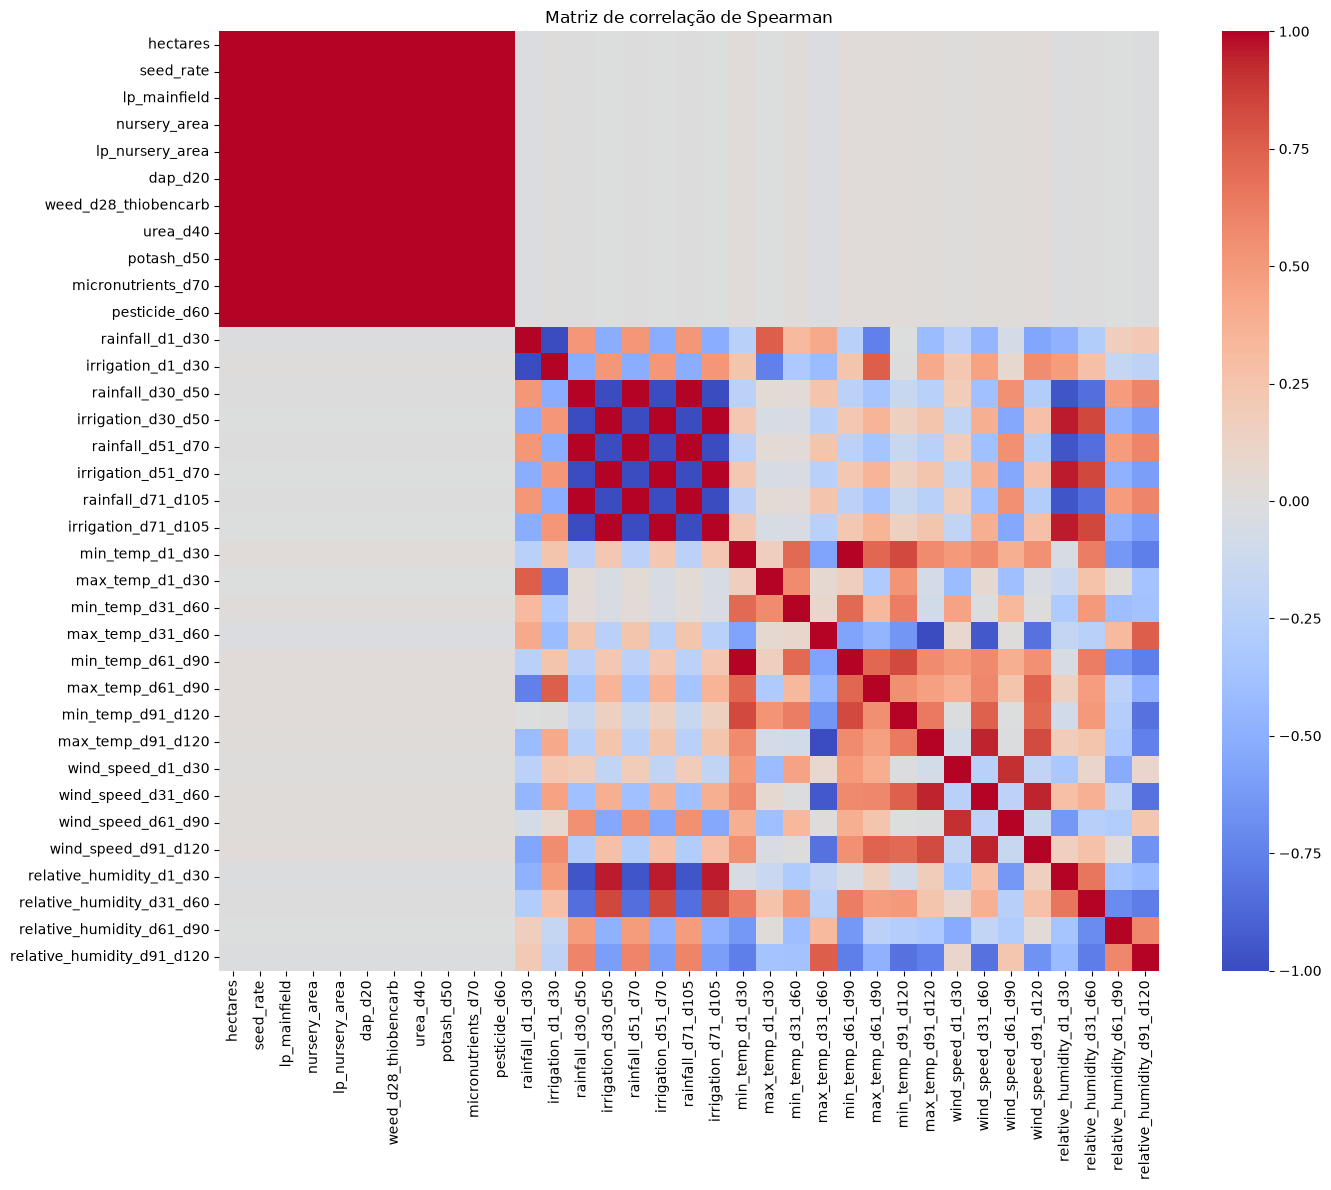

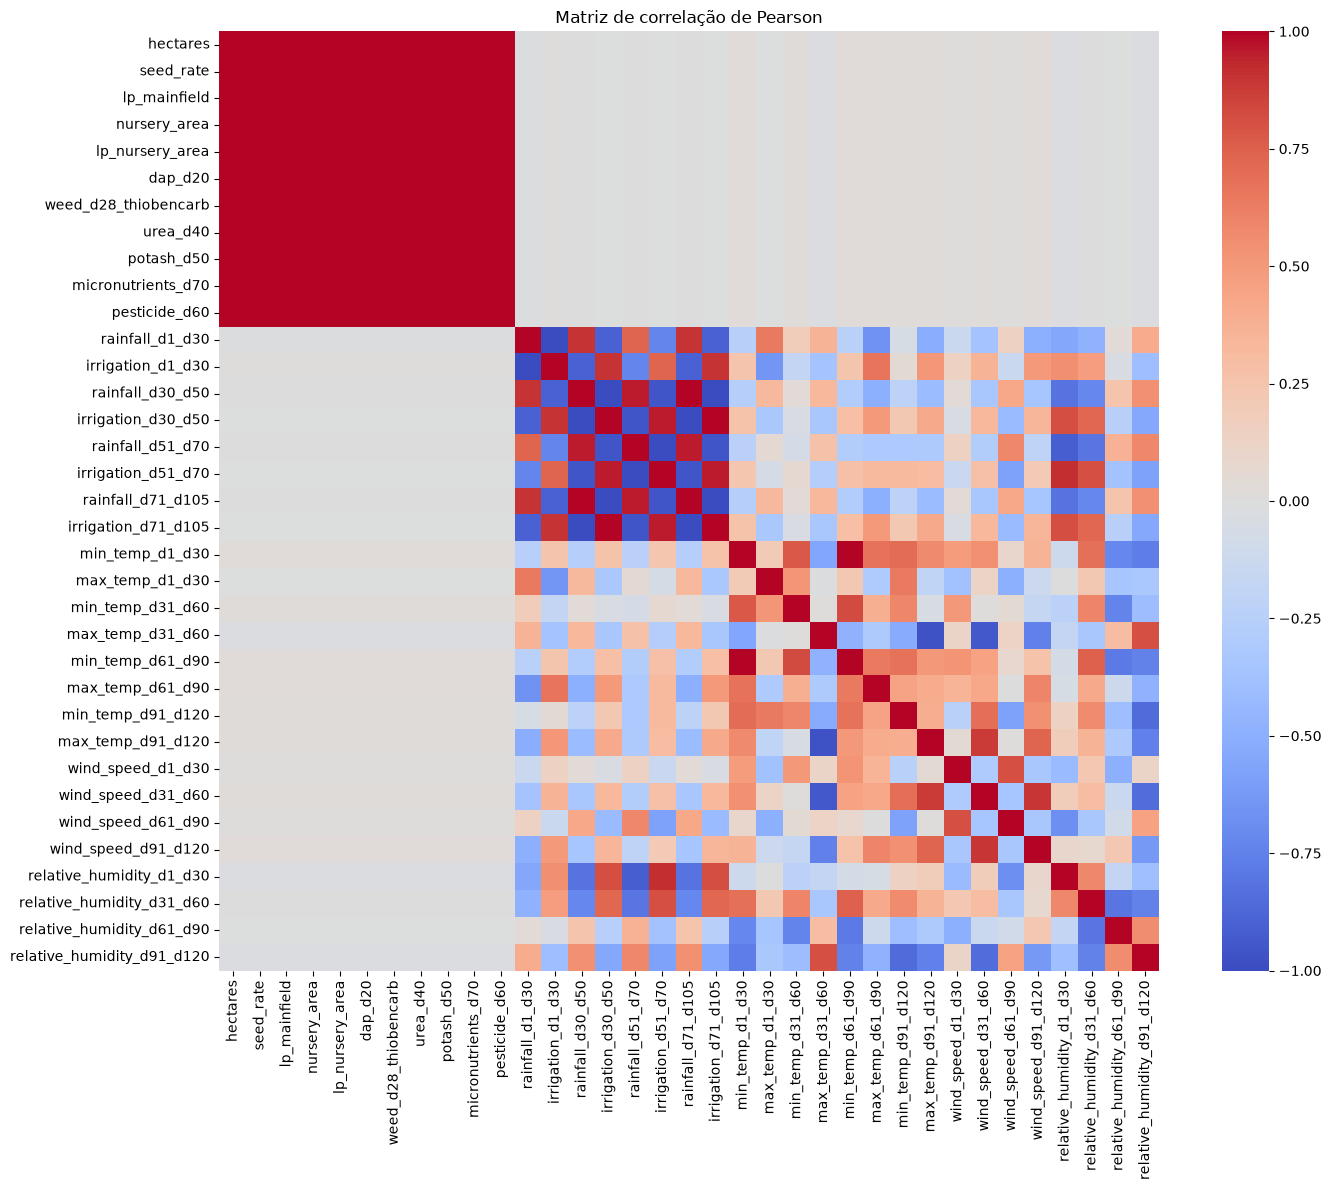

Variável 1,Variável 2,Correlação
hectares,seed_rate,1.000
hectares,lp_mainfield,1.000
seed_rate,lp_mainfield,1.000
seed_rate,micronutrients_d70,1.000
seed_rate,weed_d28_thiobencarb,1.000
seed_rate,urea_d40,1.000
seed_rate,potash_d50,1.000
seed_rate,pesticide_d60,1.000
lp_mainfield,micronutrients_d70,1.000
seed_rate,nursery_area,1.000


In [40]:
analyse_correlation(numeric_columns=scaled_df[numeric_columns])

## Remoção de características

Foram removidas, por apresentar correlação de Pearson muito alta, as seguintes características.

- hectares
- lp_mainfield
- nursery_area
- lp_nursery_area
- dap_d20
- weed_d28_thiobencarb
- urea_d40
- potash_d50
- micronutrients_d70
- pesticide_d60


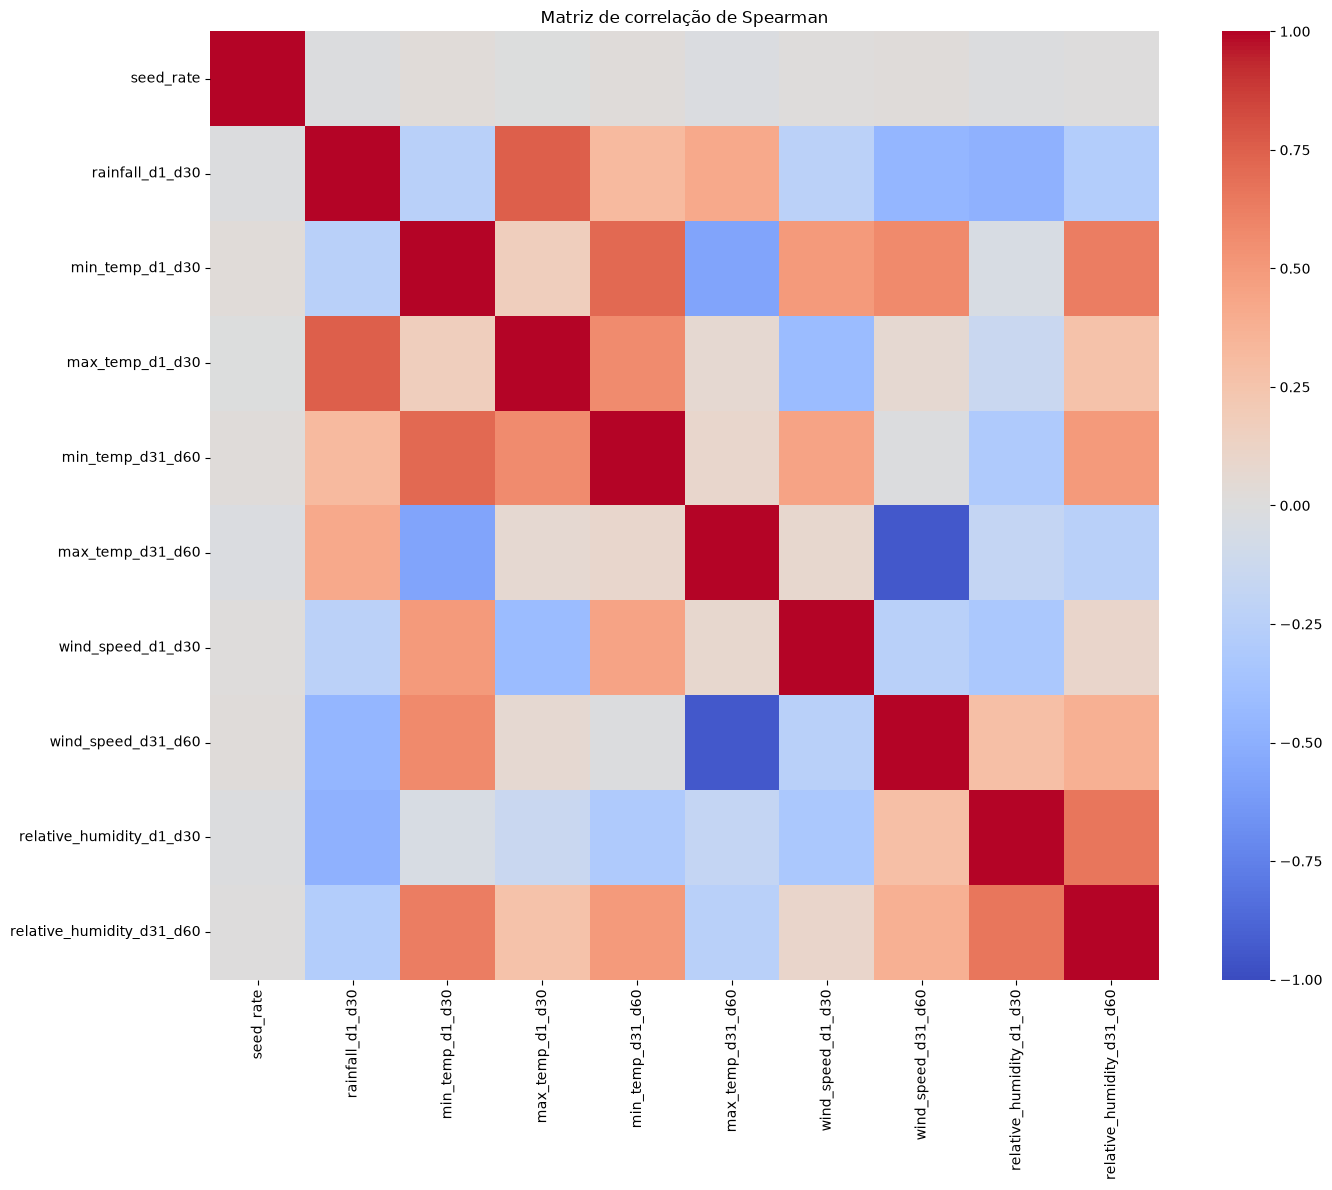

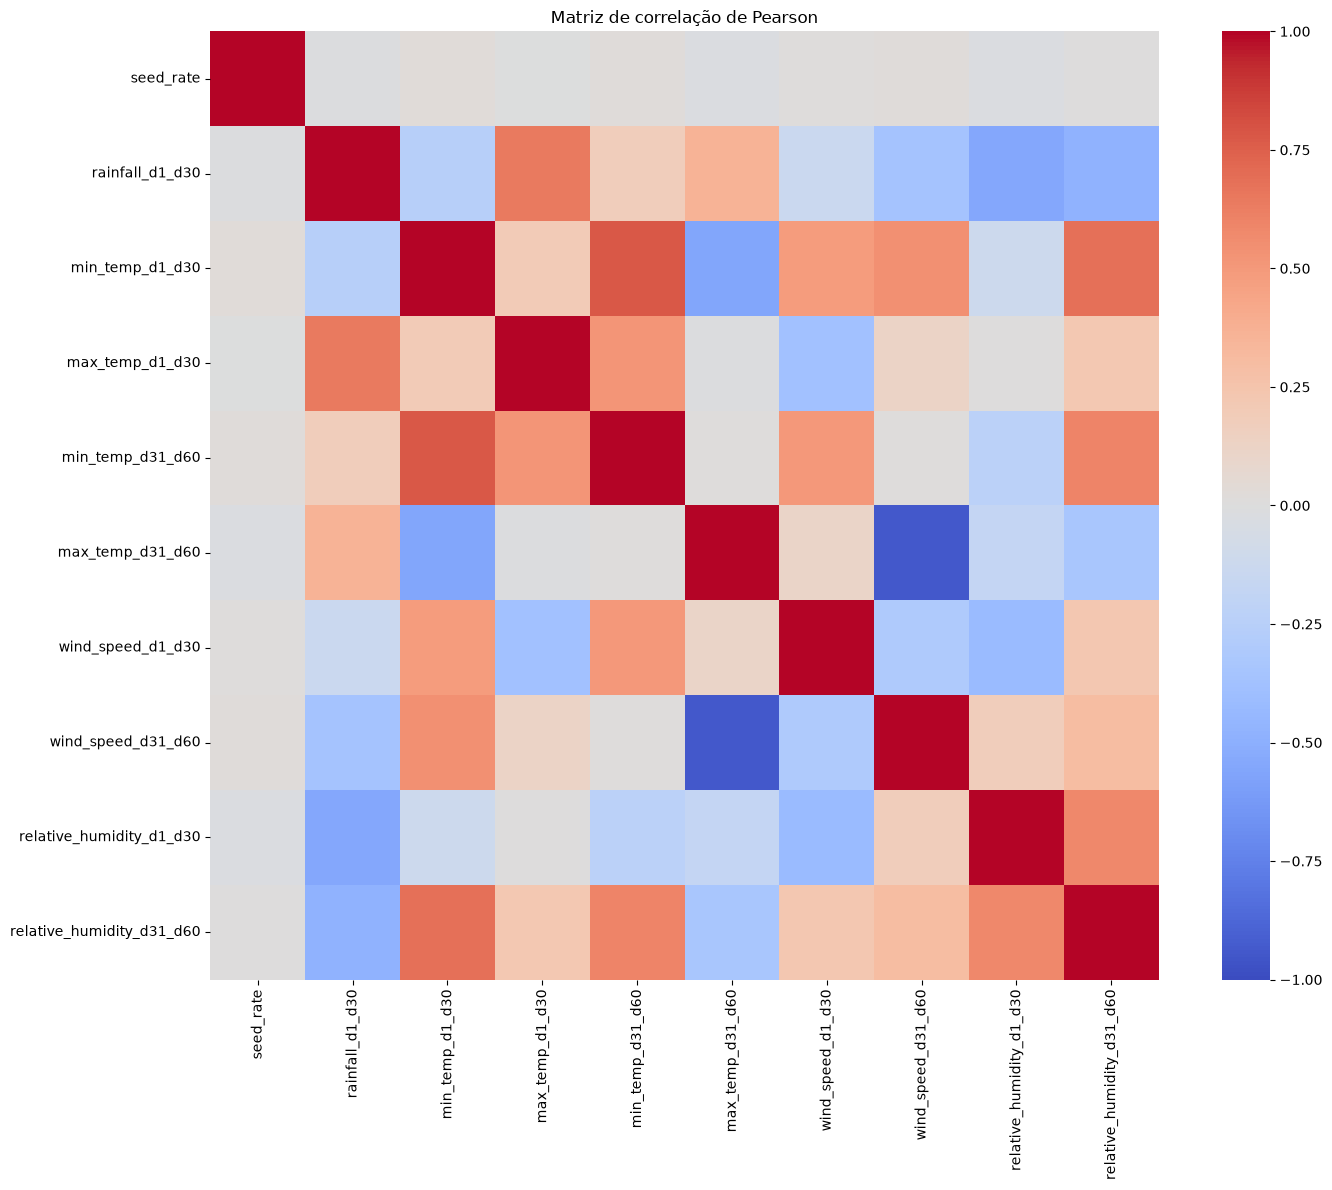

Variável 1,Variável 2,Correlação
max_temp_d31_d60,wind_speed_d31_d60,0.944


In [ ]:
filtered_df = scaled_df.copy()
filtered_numeric_columns = numeric_columns.copy()


def drop_feature(name: str):
    filtered_numeric_columns.remove(name)
    return filtered_df.drop(columns=[name])


filtered_df = drop_feature("hectares")
filtered_df = drop_feature("lp_mainfield")
filtered_df = drop_feature("nursery_area")
filtered_df = drop_feature("lp_nursery_area")
filtered_df = drop_feature("dap_d20")
filtered_df = drop_feature("weed_d28_thiobencarb")
filtered_df = drop_feature("urea_d40")
filtered_df = drop_feature("potash_d50")
filtered_df = drop_feature("micronutrients_d70")
filtered_df = drop_feature("pesticide_d60")

filtered_df = drop_feature("rainfall_d30_d50")
filtered_df = drop_feature("rainfall_d51_d70")
filtered_df = drop_feature("rainfall_d71_d105")

filtered_df = drop_feature("irrigation_d1_d30")
filtered_df = drop_feature("irrigation_d30_d50")
filtered_df = drop_feature("irrigation_d51_d70")
filtered_df = drop_feature("irrigation_d71_d105")

filtered_df = drop_feature("min_temp_d61_d90")
filtered_df = drop_feature("min_temp_d91_d120")

filtered_df = drop_feature("max_temp_d61_d90")
filtered_df = drop_feature("max_temp_d91_d120")

filtered_df = drop_feature("wind_speed_d61_d90")
filtered_df = drop_feature("wind_speed_d91_d120")

filtered_df = drop_feature("relative_humidity_d61_d90")
filtered_df = drop_feature("relative_humidity_d91_d120")


analyse_correlation(numeric_columns=filtered_df[filtered_numeric_columns])